# comprisk — competing-risk forest quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunnyadn/comprisk/blob/main/examples/01_forest_quickstart.ipynb)

`CompetingRiskForest` is a random survival forest for **competing risks**: for
each subject it estimates the cause-specific cumulative incidence (the
Aalen-Johansen CIF), and it is a real scikit-learn estimator. This notebook
walks the core loop — **fit → predict → honest evaluation → variable importance
→ variable selection**.

> Install: `pip install comprisk` (the plots below also need `matplotlib`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import comprisk
from comprisk import CompetingRiskForest

print("comprisk", comprisk.__version__)

comprisk 0.6.0


## 1. Data format

`comprisk` takes three arrays. `event[i]` encodes what happened to subject `i`:

- `event[i] == 0` → **censored** at `time[i]`
- `event[i] == k ≥ 1` → had a **cause-`k`** event at `time[i]`

Here we simulate 1000 subjects with *real signal*: cause-1 risk rises with the
first two features; the other six are noise. A competing event (cause 2) and
independent censoring also occur.

In [2]:
rng = np.random.default_rng(42)
n, p = 1000, 8

X = rng.normal(size=(n, p))
lp = X[:, 0] + 0.5 * X[:, 1]          # only feature_0, feature_1 carry signal
t1 = rng.exponential(np.exp(-lp))     # cause 1 fires sooner when lp is high
t2 = rng.exponential(2.0, size=n)     # cause 2 (competing event)
tc = rng.exponential(4.0, size=n)     # censoring time

time = np.minimum.reduce([t1, t2, tc])
event = np.where((t1 <= t2) & (t1 <= tc), 1,
                 np.where(t2 <= tc, 2, 0))      # 0 = censored

feature_names = [f"feature_{i}" for i in range(p)]
print("event counts  [censored, cause 1, cause 2] =", np.bincount(event))

event counts  [censored, cause 1, cause 2] = [134 559 307]


## 2. Fit

Defaults match randomForestSRC conventions: `n_estimators=100`,
`max_features="sqrt"`, the competing-risk log-rank split rule, and
`n_jobs=-1`.

In [3]:
forest = CompetingRiskForest(n_estimators=300, random_state=42, n_jobs=-1)
forest.fit(X, time, event)

print(f"{forest.n_estimators} trees · {forest.n_causes_} causes · "
      f"{len(forest.unique_times_)} time-grid points")

300 trees · 2 causes · 200 time-grid points


## 3. Predict cumulative incidence

`predict_cif` returns the Aalen-Johansen CIF with shape
`(n_samples, n_causes, n_times)` over the forest's own time grid
(`forest.unique_times_`).

predict_cif shape: (1000, 2, 200)


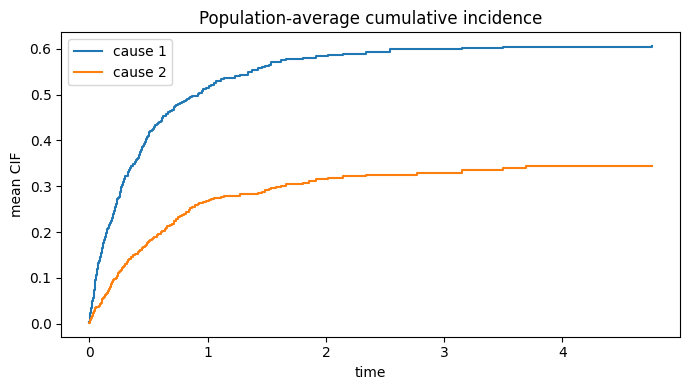

In [4]:
cif = forest.predict_cif(X)
print("predict_cif shape:", cif.shape)

grid = forest.unique_times_
fig, ax = plt.subplots(figsize=(7, 4))
for c in range(forest.n_causes_):
    ax.step(grid, cif[:, c, :].mean(axis=0), where="post", label=f"cause {c + 1}")
ax.set_xlabel("time"); ax.set_ylabel("mean CIF")
ax.set_title("Population-average cumulative incidence")
ax.legend(); fig.tight_layout()
plt.show()

## 4. Honest evaluation: out-of-bag vs in-sample

A forest can memorize its training rows, so `score(X, time, event)` on the
**training** `X` is optimistic. Use the **out-of-bag** score instead — each
subject is scored only by the trees that did not see it, so no held-out split
is needed.

In [5]:
oob = forest.oob_score(cause=1)                     # honest, out-of-sample
insample = forest.score(X, time, event, cause=1)   # optimistic
print(f"OOB  C-index (cause 1): {oob:.3f}")
print(f"In-sample C-index     : {insample:.3f}   <- optimistic, do not report this")

OOB  C-index (cause 1): 0.735
In-sample C-index     : 0.890   <- optimistic, do not report this


## 5. Permutation variable importance

Out-of-bag Breiman permutation importance, scored with the Uno IPCW C-index.
The signal-bearing features should rise to the top.

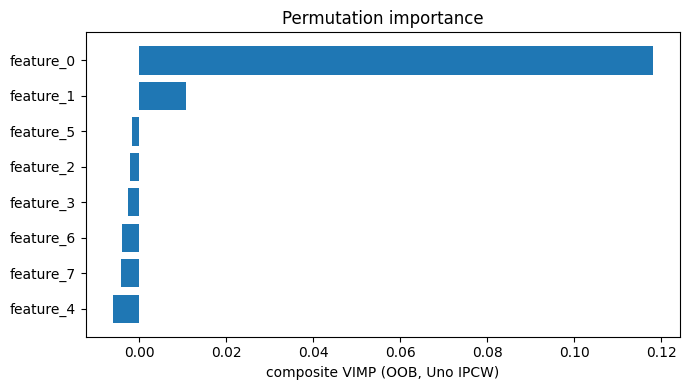

In [6]:
vimp = forest.compute_importance(random_state=42)
vimp_sorted = vimp.sort_values("composite_vimp", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(vimp_sorted["feature"][::-1], vimp_sorted["composite_vimp"][::-1])
ax.set_xlabel("composite VIMP (OOB, Uno IPCW)")
ax.set_title("Permutation importance")
fig.tight_layout()
plt.show()

In [7]:
vimp_sorted

,feature,cause_1_vimp,cause_2_vimp,composite_vimp
0,feature_0,0.122200,0.114060,0.118130
1,feature_1,0.023027,-0.001541,0.010743
5,feature_5,0.000909,-0.004185,-0.001638
2,feature_2,-0.001837,-0.002207,-0.002022
3,feature_3,-0.001680,-0.003296,-0.002488
6,feature_6,-0.003288,-0.004425,-0.003857
7,feature_7,0.000755,-0.009123,-0.004184
4,feature_4,-0.003400,-0.008556,-0.005978


## 6. Variable selection — Ishwaran minimal depth

A complementary, permutation-free selector: features that split close to the
root (small mean minimal depth) are important. `minimal_depth()` applies
Ishwaran's (2010) mean-minimal-depth threshold and flags the survivors.

In [8]:
md = forest.minimal_depth()
selected = md.query("selected")["feature"].tolist()
print("selected:", selected)
md

selected: ['feature_0', 'feature_1', 'feature_4']


,feature,mean_min_depth,threshold,selected
0,feature_0,0.933333,2.13075,True
1,feature_1,1.340000,2.13075,True
2,feature_4,2.130000,2.13075,True
3,feature_6,2.520000,2.13075,False
4,feature_2,2.793333,2.13075,False
5,feature_7,2.850000,2.13075,False
6,feature_5,2.866667,2.13075,False
7,feature_3,2.956667,2.13075,False


## Next

- **Regression models** — Fine-Gray, cause-specific Cox, Gray's test, penalized
  Fine-Gray: [`02_regression_models.ipynb`](02_regression_models.ipynb)
- **TreeSHAP explanations** (interactive marimo app): `examples/shap_explain.py`
- Full reference: [`docs/quickstart.md`](../docs/quickstart.md)